In [1]:
# ==========================================
# MACHINE LEARNING TASK 2
# Support Ticket Classification & Prioritization
# Part 1: Load and Prepare Dataset
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Load dataset
df = pd.read_csv("../data/customer_support_tickets.csv")

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Dataset information
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

# Remove rows with completely missing values
df = df.dropna(how="all")

print("\nDataset Shape After Basic Cleaning:")
print(df.shape)

First 5 rows:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0



Dataset Shape:
(8469, 17)

Column Names:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']

Missing Values:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Ra

In [2]:
# ==========================================
# PART 2: EXPLORE AND PREPARE THE DATA
# ==========================================

# Show all column names clearly
print("AVAILABLE COLUMNS:\n")
for col in df.columns:
    print("-", col)

# Display a few complete rows
print("\nSAMPLE DATA:\n")
display(df.head(3))

# Check unique values in likely category columns
possible_columns = [
    "Ticket Type",
    "Ticket Priority",
    "Ticket Subject",
    "Ticket Description"
]

print("\nIMPORTANT COLUMN CHECK:\n")

for col in possible_columns:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].dropna().unique()[:20])

# Check missing values again for important columns
print("\nMISSING VALUES IN IMPORTANT COLUMNS:\n")

for col in possible_columns:
    if col in df.columns:
        print(f"{col}: {df[col].isnull().sum()}")

AVAILABLE COLUMNS:

- Ticket ID
- Customer Name
- Customer Email
- Customer Age
- Customer Gender
- Product Purchased
- Date of Purchase
- Ticket Type
- Ticket Subject
- Ticket Description
- Ticket Status
- Resolution
- Ticket Priority
- Ticket Channel
- First Response Time
- Time to Resolution
- Customer Satisfaction Rating

SAMPLE DATA:



,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0



IMPORTANT COLUMN CHECK:


Ticket Type:
['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']

Ticket Priority:
['Critical' 'Low' 'High' 'Medium']

Ticket Subject:
['Product setup' 'Peripheral compatibility' 'Network problem'
 'Account access' 'Data loss' 'Payment issue' 'Refund request'
 'Battery life' 'Installation support' 'Software bug' 'Hardware issue'
 'Product recommendation' 'Delivery problem' 'Display issue'
 'Cancellation request' 'Product compatibility']

Ticket Description:
["I'm having an issue with the {product_purchased}. Please assist.\n\nYour billing zip code is: 71701.\n\nWe appreciate that you have requested a website address.\n\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists."
 "I'm having an issue with the {product_purchased}. Please assist.\n\nIf you need to change an existing product.\n\nI'm having an issue with the {product_purchased}. Please

In [3]:
# ==========================================
# PART 3: TEXT PREPROCESSING + ML MODELS
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ------------------------------------------
# 1. Combine Ticket Subject and Description
# ------------------------------------------

df["Ticket Subject"] = df["Ticket Subject"].fillna("")
df["Ticket Description"] = df["Ticket Description"].fillna("")

df["Ticket Text"] = (
    df["Ticket Subject"] + " " + df["Ticket Description"]
)

# ------------------------------------------
# 2. Text Cleaning Function
# ------------------------------------------

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Clean Text"] = df["Ticket Text"].apply(clean_text)

# Remove empty text rows
df = df[df["Clean Text"].str.strip() != ""]

print("Sample Cleaned Text:")
print(df["Clean Text"].head())

# ------------------------------------------
# 3. CATEGORY CLASSIFICATION DATA
# ------------------------------------------

X = df["Clean Text"]
y_category = df["Ticket Type"]

# Remove missing categories
valid_category = y_category.notna()

X_category = X[valid_category]
y_category = y_category[valid_category]

# Split data
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_category,
    y_category,
    test_size=0.2,
    random_state=42,
    stratify=y_category
)

# ------------------------------------------
# 4. TF-IDF TEXT VECTORIZATION
# ------------------------------------------

tfidf_category = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_cat_tfidf = tfidf_category.fit_transform(X_train_cat)
X_test_cat_tfidf = tfidf_category.transform(X_test_cat)

print("\nTF-IDF feature matrix created successfully!")
print("Training shape:", X_train_cat_tfidf.shape)
print("Testing shape:", X_test_cat_tfidf.shape)

# ------------------------------------------
# 5. TRAIN CATEGORY MODEL
# ------------------------------------------

category_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

category_model.fit(
    X_train_cat_tfidf,
    y_train_cat
)

print("\nCategory Classification Model trained successfully!")

# ------------------------------------------
# 6. PRIORITY CLASSIFICATION DATA
# ------------------------------------------

y_priority = df["Ticket Priority"]

valid_priority = y_priority.notna()

X_priority = X[valid_priority]
y_priority = y_priority[valid_priority]

X_train_pri, X_test_pri, y_train_pri, y_test_pri = train_test_split(
    X_priority,
    y_priority,
    test_size=0.2,
    random_state=42,
    stratify=y_priority
)

# Separate TF-IDF vectorizer for priority prediction
tfidf_priority = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_pri_tfidf = tfidf_priority.fit_transform(X_train_pri)
X_test_pri_tfidf = tfidf_priority.transform(X_test_pri)

print("\nPriority TF-IDF feature matrix created!")

# ------------------------------------------
# 7. TRAIN PRIORITY MODEL
# ------------------------------------------

priority_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

priority_model.fit(
    X_train_pri_tfidf,
    y_train_pri
)

print("\nPriority Classification Model trained successfully!")

print("\n==========================================")
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("==========================================")

Sample Cleaned Text:
0    product setup i m having an issue with the pro...
1    peripheral compatibility i m having an issue w...
2    network problem i m facing a problem with my p...
3    account access i m having an issue with the pr...
4    data loss i m having an issue with the product...
Name: Clean Text, dtype: object

TF-IDF feature matrix created successfully!
Training shape: (6775, 5000)
Testing shape: (1694, 5000)

Category Classification Model trained successfully!

Priority TF-IDF feature matrix created!

Priority Classification Model trained successfully!

ALL MODELS TRAINED SUCCESSFULLY!


CATEGORY CLASSIFICATION RESULTS
Accuracy: 20.72 %

Classification Report:
                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.21      0.20       327
Cancellation request       0.18      0.20      0.19       339
     Product inquiry       0.22      0.24      0.23       328
      Refund request       0.20      0.17      0.18       351
     Technical issue       0.24      0.22      0.23       349

            accuracy                           0.21      1694
           macro avg       0.21      0.21      0.21      1694
        weighted avg       0.21      0.21      0.21      1694



<Figure size 1000x700 with 0 Axes>

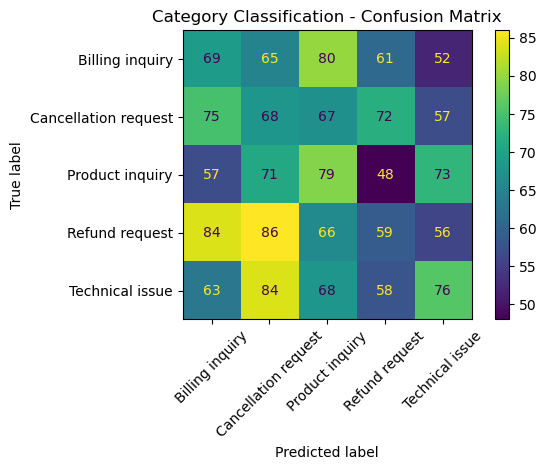


PRIORITY CLASSIFICATION RESULTS
Accuracy: 25.32 %

Classification Report:
              precision    recall  f1-score   support

    Critical       0.25      0.25      0.25       426
        High       0.26      0.26      0.26       417
         Low       0.23      0.25      0.24       413
      Medium       0.28      0.25      0.27       438

    accuracy                           0.25      1694
   macro avg       0.25      0.25      0.25      1694
weighted avg       0.25      0.25      0.25      1694



<Figure size 800x600 with 0 Axes>

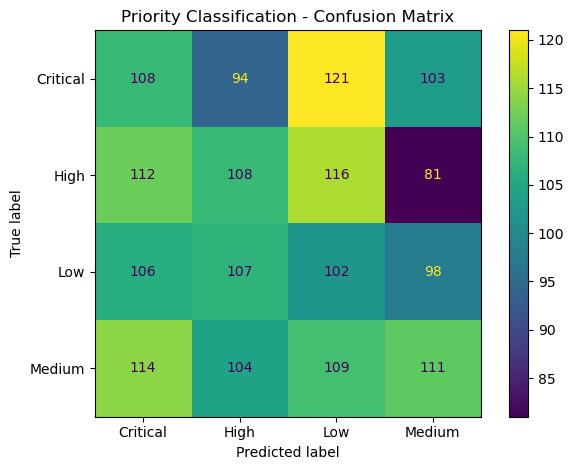


SAMPLE SUPPORT TICKET PREDICTIONS

Ticket: I was charged twice for my subscription payment
Predicted Category: Product inquiry
Predicted Priority: Low

Ticket: My application keeps crashing when I try to login
Predicted Category: Cancellation request
Predicted Priority: High

Ticket: I want to know how to change my account details
Predicted Category: Billing inquiry
Predicted Priority: High

Ticket: The website is not loading and I cannot access my account
Predicted Category: Refund request
Predicted Priority: Critical

FINAL MODEL SUMMARY
Category Classification Accuracy: 20.72%
Priority Classification Accuracy: 25.32%

Task 2 completed successfully!


In [4]:
# ==========================================
# PART 4: MODEL EVALUATION AND VISUALIZATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------
# 1. CATEGORY MODEL PREDICTIONS
# ------------------------------------------

category_predictions = category_model.predict(X_test_cat_tfidf)

category_accuracy = accuracy_score(
    y_test_cat,
    category_predictions
)

print("==========================================")
print("CATEGORY CLASSIFICATION RESULTS")
print("==========================================")

print("Accuracy:", round(category_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test_cat,
        category_predictions
    )
)

# ------------------------------------------
# 2. CATEGORY CONFUSION MATRIX
# ------------------------------------------

category_cm = confusion_matrix(
    y_test_cat,
    category_predictions,
    labels=category_model.classes_
)

plt.figure(figsize=(10, 7))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=category_cm,
    display_labels=category_model.classes_
)

display_cm.plot(
    xticks_rotation=45
)

plt.title("Category Classification - Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/category_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------
# 3. PRIORITY MODEL PREDICTIONS
# ------------------------------------------

priority_predictions = priority_model.predict(X_test_pri_tfidf)

priority_accuracy = accuracy_score(
    y_test_pri,
    priority_predictions
)

print("\n==========================================")
print("PRIORITY CLASSIFICATION RESULTS")
print("==========================================")

print("Accuracy:", round(priority_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test_pri,
        priority_predictions
    )
)

# ------------------------------------------
# 4. PRIORITY CONFUSION MATRIX
# ------------------------------------------

priority_cm = confusion_matrix(
    y_test_pri,
    priority_predictions,
    labels=priority_model.classes_
)

plt.figure(figsize=(8, 6))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=priority_cm,
    display_labels=priority_model.classes_
)

display_cm.plot()

plt.title("Priority Classification - Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/priority_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------
# 5. SAMPLE PREDICTIONS
# ------------------------------------------

print("\n==========================================")
print("SAMPLE SUPPORT TICKET PREDICTIONS")
print("==========================================")

sample_tickets = [
    "I was charged twice for my subscription payment",
    "My application keeps crashing when I try to login",
    "I want to know how to change my account details",
    "The website is not loading and I cannot access my account"
]

for ticket in sample_tickets:

    cleaned_ticket = clean_text(ticket)

    # Category prediction
    category_vector = tfidf_category.transform(
        [cleaned_ticket]
    )

    predicted_category = category_model.predict(
        category_vector
    )[0]

    # Priority prediction
    priority_vector = tfidf_priority.transform(
        [cleaned_ticket]
    )

    predicted_priority = priority_model.predict(
        priority_vector
    )[0]

    print("\nTicket:", ticket)
    print("Predicted Category:", predicted_category)
    print("Predicted Priority:", predicted_priority)


# ------------------------------------------
# 6. FINAL SUMMARY
# ------------------------------------------

print("\n==========================================")
print("FINAL MODEL SUMMARY")
print("==========================================")

print(
    f"Category Classification Accuracy: "
    f"{category_accuracy * 100:.2f}%"
)

print(
    f"Priority Classification Accuracy: "
    f"{priority_accuracy * 100:.2f}%"
)

print("\nTask 2 completed successfully!")